In [1]:
import numpy as np
import scipy
import csv
import matplotlib.pyplot as plt

!python3 -m pip install py3gpp
from py3gpp import *

In [2]:
# input_file = 'waveform_IQComplex_fllay.csv'
input_file = '/home/tiwat/workarea/IQ_constellation/iq_python/input/fllay_092024/waveform_IQComplex_fllay.csv'

waveform = []
with open(input_file, 'r') as f:
    reader = csv.reader(f)
    for row in reader:
      IQComplex = row[0].strip()
      IQComplex = IQComplex.replace('i','j')
      IQComplex = complex(IQComplex)
      waveform.append(IQComplex)

/home/tiwat/workarea/IQ_constellation/iq_python/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tiwat/workarea/IQ_constellation/iq_python/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'magnitude_real')

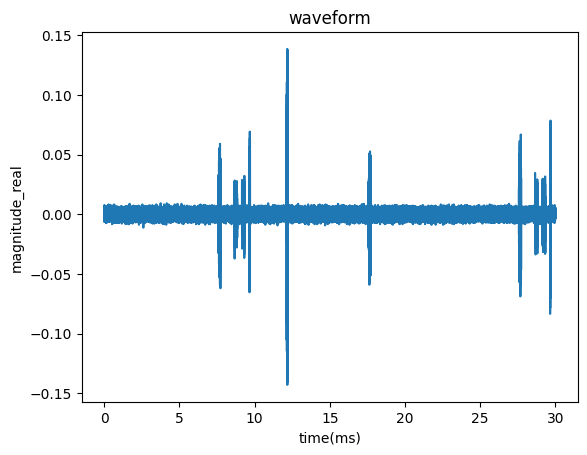

In [3]:
sampleRate = 15.36e6                            # samples per second
# fPhaseComp = 3.48384e+09
# minChannelBW = 10
# BlockPattern = "Case C"
# L_max = 8

nrbSSB = 20
mu = 1
scs = 15 * 2**mu
carrier = nrCarrierConfig(NSizeGrid = nrbSSB, SubcarrierSpacing = scs)
rxOfdmInfo = nrOFDMInfo(carrier)
Nfft = rxOfdmInfo['Nfft']                       # number of FFT samples

t = np.arange(len(waveform))/sampleRate
# plot original waveform
plt.plot(t*1e3, waveform)
plt.title('waveform'); plt.xlabel('time(ms)'); plt.ylabel('magnitude_real')

## PSS Search and Frequency Offset Correction

In [4]:
searchBW = 6*scs
rxSampleRate = sampleRate
kPSS = np.arange((119-63), (119+64))    # np.arange(56, 183) # check on 3GPP standard 

fshifts = np.arange(-searchBW, searchBW+scs, scs)*1e3/2     # half subcarrier step
peak_value = np.zeros((len(fshifts),3))
peak_index = np.zeros((len(fshifts),3), 'int')
# period = number of point / sample frequency       T = N/Fs
t = np.arange(len(waveform))/rxSampleRate

In [5]:
# With downsampling
syncNfft = 256                  # minimum FFT Size to cover SS burst
syncSR = syncNfft * scs * 1e3

for fIdx in np.arange(len(fshifts), dtype='int'):
    coarseFrequencyOffset = fshifts[fIdx]
    rxWaveformFreqCorrected = waveform * np.exp(-1j*2*np.pi*coarseFrequencyOffset*t)
    # if refWaveform is not downsample, the input waveform can do without downsample
    # rxWaveformDS = scipy.signal.decimate(rxWaveformFreqCorrected, int(rxSampleRate/syncSR), ftype='fir')  # py3gpp use decimate instead of resample_poly
    rxWaveformDS = scipy.signal.resample_poly(rxWaveformFreqCorrected, syncSR, rxSampleRate)              # same with matlab code

    for NID2 in np.arange(3, dtype='int'):
        slotGrid = nrResourceGrid(carrier)
        slotGrid  = slotGrid[:,0] 
        slotGrid[kPSS] = nrPSS(NID2)

        nSlot = 0
        # [refWaveform, info] = nrOFDMModulate(carrier=carrier, grid=slotGrid, scs=scs, initialNSlot=nSlot, SampleRate=rxSampleRate)    # no downsample anymore
        # [refWaveform, info] = nrOFDMModulate(carrier=carrier, grid=slotGrid, SampleRate=rxSampleRate)                               # same with above
        [refWaveform, info] = nrOFDMModulate(carrier=carrier, grid=slotGrid, scs=scs, initialNSlot=nSlot, SampleRate=syncSR, Nfft=syncNfft)     # mod w/ downsample sample rate
        refWaveform = refWaveform[info['CyclicPrefixLengths'][0]:]; # remove CP
        
        # temp = scipy.signal.correlate(rxWaveformFreqCorrected, refWaveform,'valid')     # cross correlate waveform & refWaveform
        temp = scipy.signal.correlate(rxWaveformDS, refWaveform,'valid') 
        # t_corr = np.arange(temp.shape[0])/rxSampleRate*1e3                               # for plotting t_corr vs temp
        # t_corr = np.arange(temp.shape[0])/syncSR*1e3

        peak_index[fIdx, NID2] = np.argmax(np.abs(temp))
        peak_value[fIdx, NID2] = np.abs(temp[peak_index[fIdx, NID2]])

select_fIdx, select_NID2 = np.where(peak_value == np.max(peak_value))
coarseFrequencyOffset = fshifts[select_fIdx]

print("max_corr", np.max(peak_value))
print("coarseFrequencyOffset", coarseFrequencyOffset, "NID2", NID2)


max_corr 0.23058730841798264
coarseFrequencyOffset [45000.] NID2 2


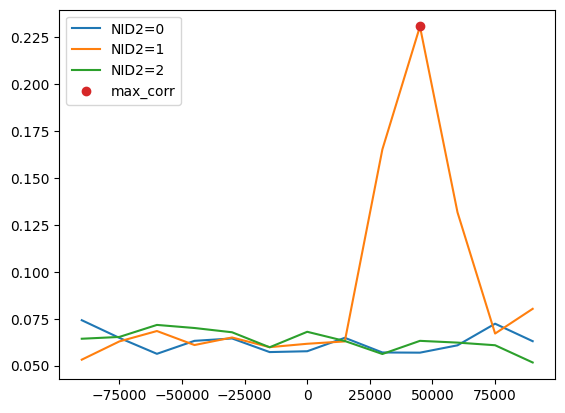

In [6]:
# plotting result
plt.plot(fshifts, peak_value)                               
plt.plot(coarseFrequencyOffset, np.max(peak_value), 'o')
plt.legend(['NID2=0', 'NID2=1', 'NID2=2', 'max_corr'])

In [7]:
# apply coarseFrequencyCorrect, and downsample
rxWaveformFreqCorrected =  waveform * np.exp(-1j*2*np.pi*coarseFrequencyOffset*t)
rxWaveformDS = scipy.signal.resample_poly(rxWaveformFreqCorrected, syncSR, rxSampleRate)  

In [8]:
# offset = peak_index[select_fIdx, select_NID2] + syncOfdmInfo.SymbolLengths
# To find fine frequency offset, we shift by peak_index + syncOfdmInfo.SymbolLengths, to get "useful" OFDM symbol,
# by shift a SymbolLength (CP + data). The CP = [22, 18, 18, ...], syncOfdmInfo.SymbolLengths = [278, 274, 274, ...]
# As we shift from the first symbol, we use syncOfdmInfo.SymbolLengths[1] = 278
# no minus 1, we want at the offset location

syncOfdmInfo_SymbolLengths = 278
offset = int(peak_index[select_fIdx, select_NID2] + syncOfdmInfo_SymbolLengths)
# print(peak_index[select_fIdx, select_NID2], offset)

/tmp/ipykernel_10940/3038441655.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  offset = int(peak_index[select_fIdx, select_NID2] + syncOfdmInfo_SymbolLengths)


/home/tiwat/workarea/IQ_constellation/iq_python/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tiwat/workarea/IQ_constellation/iq_python/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


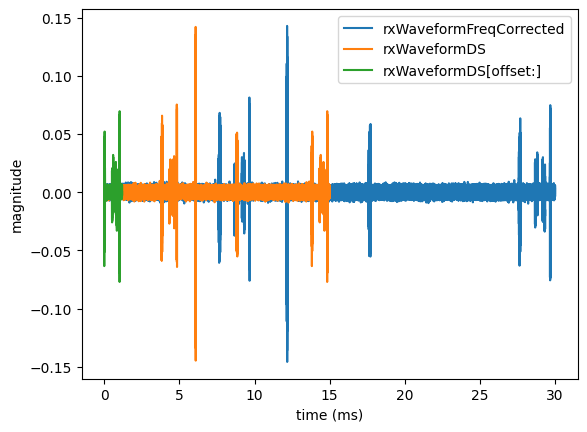

In [9]:
# compare waveformCFO, waveformDS, waveformDSOffset
t_plot = (np.arange(len(rxWaveformFreqCorrected))/rxSampleRate)*1e3
plt.plot(t_plot, rxWaveformFreqCorrected, label='rxWaveformFreqCorrected')
t_plot2 = (np.arange(len(rxWaveformDS))/rxSampleRate)*1e3
plt.plot(t_plot2, rxWaveformDS, label='rxWaveformDS')
t_plot3 = (np.arange(len(rxWaveformDS[offset:]))/rxSampleRate)*1e3
plt.plot(t_plot3, rxWaveformDS[offset:], label='rxWaveformDS[offset:]')
plt.xlabel('time (ms)'); plt.ylabel('magnitude'); plt.legend()

In [10]:
# from hssBurstFineFrequencyOffset
# waveform = rxWaveformDS[offset:]
# ofdmInfo = syncOfdmInfo

# determine cyclic prefix from syncOfdmInfo
CyclicPrefix = "normal"
SampleRate = syncSR

# from nrOFDMDemodulate
mu = (scs // 15) - 1
if CyclicPrefix == "normal":
    N_cp1 = int(((144) * 2 ** (-mu) + 16) * (SampleRate / 30720000))
    N_cp2 = int((144 * 2 ** (-mu)) * (SampleRate / 30720000))
else:
    N_cp1 = int((512 * 2 ** (-mu)) * (SampleRate / 30720000))
    N_cp2 = N_cp1
N_cp = np.zeros(carrier.SymbolsPerSlot, dtype=int)
for i in range(len(N_cp)):
    N_cp[i] = N_cp1 if i == 0 or i == 7 * 2 ** (mu) else N_cp2

print('CyclicPrefix', N_cp)

# OFDM symbol = CP + Useful FFT
Lcp = N_cp[1]       # cyclic prefix samples
Lu = syncNfft       # useful samples
Lysm = Lcp + Lu     # number of time downsamples in an OFDM symbol
print('Lcp Lu Lysm:', Lcp, Lu, Lysm)

CyclicPrefix [22 18 18 18 18 18 18 18 18 18 18 18 18 18]
Lcp Lu Lysm: 18 256 274


Text(0.5, 0, 'time (ms)')

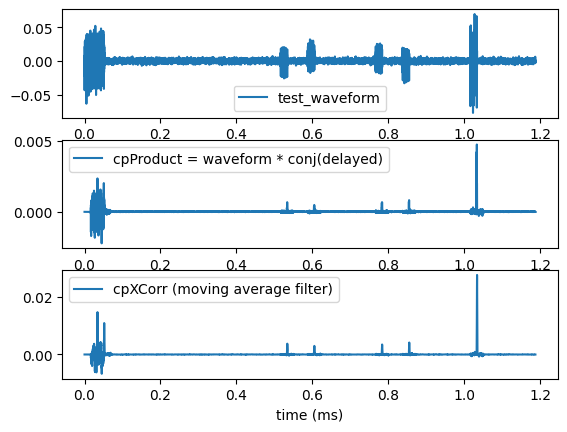

In [11]:
# Apply the waveform by itself delayed by Lu samples and conjugated
# yield correlation between waveform and waveform with delayed
test_waveform = rxWaveformDS[offset:]
delayed = np.concatenate((np.zeros(Lu, dtype=int), test_waveform[:len(test_waveform) - Lu]))
cpProduct = test_waveform * np.conjugate(delayed)

# Apply a moving sum filter with a window size equal to the CP length
# moving average further reduce noise and accumulate evidence of correlation 
cpXCorr = scipy.signal.lfilter(np.ones(Lcp), 1, cpProduct)

# compare waveformDS[offset:], cpProduct, cpXCorr 
t_plot = np.arange(len(test_waveform))/rxSampleRate *1e3
fig, axes = plt.subplots(3,1)
axes[0].plot(t_plot, test_waveform, label='test_waveform')
axes[0].legend()
axes[1].plot(t_plot, cpProduct, label = 'cpProduct = waveform * conj(delayed)')
axes[1].legend()
axes[2].plot(t_plot, cpXCorr, label='cpXCorr (moving average filter)')
axes[2].legend()
axes[2].set_xlabel('time (ms)')

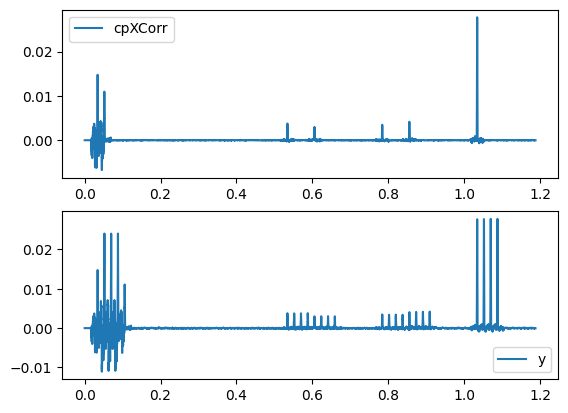

In [12]:
# Moving sum over 4 OFDM symbols (Lysm (length OFDM symbol))
# cpxCorr = [PSS][PBCH    ][SSS         ][PBCH          ]...                             => SS Block Size
# cpXCorr   [0  ][PSS     ][PBCH        ][SSS           ][PBCH     ]...
# k=1       [PSS][PSS+PBCH][SSS+PBCH    ][PBCH+SSS      ][PBCH     ]...
# k=2       [PSS][PSS+PBCH][SSS+PBCH+PSS][2PBCH+SSS     ][PBCH+SSS ][PBCH    ]...
# k=3       [PSS][PSS+PBCH][SSS+PBCH+PSS][*2PBCH+SSS+PSS][2PBCH+SSS][PBCH+SSS]...
# get all compilation, instead of correlation over one symbol, will do over one SS Block (4 Symbols)
y = cpXCorr
cpXCorrDelayed = cpXCorr
for k in [1,2,3]:
    cpXCorrDelayed = np.concatenate((np.zeros(Lysm, dtype=int), cpXCorrDelayed[:len(cpXCorrDelayed) - Lysm]))
    y = y + cpXCorrDelayed

fig, axes = plt.subplots(2, 1)
t_plot = np.arange(len(y))/rxSampleRate *1e3
axes[0].plot(t_plot, cpXCorr, label='cpXCorr'); axes[0].legend()
axes[1].plot(t_plot, y, label='y'); axes[1].legend()

confuse on the below cell \
may read more on: 
- https://dspillustrations.com/pages/pages/courses/course_OFDM/html/07%20-%20OFDM%20Channel%20Estimation%20%282%29.html
- https://destevez.net/2023/08/demodulation-of-the-5g-nr-downlink/

In [13]:
##  Extract the correlation peak, average over the receive antennas, them compute phase and corresponding frequency offset
# length of sum average windows
cpCorrIndex = Lu + Lcp + 3*Lysm     ##  4*Lysm = Lu (delayed correlation) + Lcp (sum filter CP) + 3*Lysm(moving sum filter of 4 symbols)

## from phase rotation of each subcarrier, we can estimate small frequency correction
scsHz = syncSR/syncNfft
# average because If there's true frequency offset, all correlations rotate similarly
# phase (rad/sec) / 2pi (rad) => 1/s (Hz) ---> get frequency, then multiply subcarriers
fineFrequencyOffset = scsHz * np.angle(np.mean(y[cpCorrIndex:])) / (2*np.pi)          # average corr -> find angle (phase) -> divide by 2pi to convert to Hz                      


## Total Frequency Offset
frequencyOffset = coarseFrequencyOffset + fineFrequencyOffset

## MATLAB fineFrequencyOffset = -1697.2 Hz, frequencyoffset = 43303.04 Hz
# our result are different since our peak_index is difference from MATLAB (the location detecting the same peak_value come from different index)
print("coarseFrequencyOffset: %d Hz \nfineFrequencyOffset %.4f Hz" %(coarseFrequencyOffset.item(), fineFrequencyOffset.item()))
print(f"frequencyOffset: %.4f Hz" %(frequencyOffset.item()))

## apply coarse and fine frequency correction to the waveform
waveform = waveform * np.exp(-1j*2*np.pi*frequencyOffset*t)

coarseFrequencyOffset: 45000 Hz 
fineFrequencyOffset -1645.0526 Hz
frequencyOffset: 43354.9474 Hz


## Time Synchronisation and OFDM Demodulation

In [14]:
# timingOffset = nrTimingEstimate(rxWaveform, nrbSSB, scsSSB, nSlot, refGrid, 'SampleRate', sampleRate)
slotGrid = nrResourceGrid(carrier)
slotGrid  = slotGrid[:,0] 
slotGrid[kPSS] = nrPSS(select_NID2)
nSlot = 0

# remove CP
[refWaveform, info] = nrOFDMModulate(carrier=carrier, grid=slotGrid, scs=scs, initialNSlot=nSlot, SampleRate=rxSampleRate, Nfft=Nfft) 
refWaveform = refWaveform[info['CyclicPrefixLengths'][0]:]; # remove CP 

# find timing offset of the OFDM symbol prior to the detected SSB due to the content of the refGrid/slotGrid
temp = scipy.signal.correlate(waveform, refWaveform,'valid') 
timingOffset = np.argmax(np.abs(temp))

## Start here
### rxGrid wrong

In [15]:
## After frequency offset correction, the receiver can assume that the center frequencies of the reference PSS and received waveform are aligned. 
# Finally, the receiver OFDM demodulates the synchronized waveform and extracts the SS block.

# from py3gpp
# rxGrid = nrOFDMDemodulate(waveform = waveform[timingOffset:][:np.min((waveform.shape[0], 2048))], nrb = nrbSSB, scs = scs, initialNSlot = nSlot, SampleRate=rxSampleRate, CyclicPrefixFraction=0.5)

rxGrid = nrOFDMDemodulate(waveform=waveform[1+timingOffset:], nrb=nrbSSB, scs=scs, initialNSlot=nSlot, SampleRate=rxSampleRate)
# extract SSB (SS Block)
rxGrid = rxGrid[:, 1:5]


## SymbolLengths are measured in FFT samples, scale the symbolLength 
# subcarrier spacing * number of FFT samples = sampling rate (scs * Nfft = rxSamplingRate)
srRatio = rxSampleRate/(scs *1e3 *Nfft)     # srRatio = 1 => Nyquist Rate (minimum sampling rate to accutately capture signal's information)
rxOfdmInfo_SymbolLengths = 548              # from MATLAB
firstSymbolLength = rxOfdmInfo_SymbolLengths * srRatio
print("Time offset to synchronizationm block: %d" %(timingOffset+firstSymbolLength), " samples (%.4f ms)" % ((timingOffset+firstSymbolLength)/rxSampleRate*1e3)) 

Time offset to synchronizationm block: 424296  samples (27.6234 ms)


In [16]:
rxGrid

array([[-4.53155342e-01+4.26025583e-02j, -8.34104922e-02-7.77873161e-01j,
         6.06538268e-02+6.98808450e-01j,  8.46689279e-03+7.15811853e-02j],
       [-5.20989460e-01-2.73761646e-01j,  5.30856394e-01+3.06020751e-01j,
        -5.61300234e-01-4.28800292e-01j,  6.83624579e-02-2.77849628e-02j],
       [ 6.31611791e-01+3.58216408e-02j,  2.29678657e-01+4.87326041e-01j,
        -1.94667977e-01-5.61751118e-01j,  1.65009767e-02-5.06252056e-02j],
       [ 6.44604630e-01+4.50138237e-01j,  7.58183492e-01+1.72103147e-02j,
        -5.95822847e-01+5.54648088e-02j,  6.05634604e-02+1.66278228e-02j],
       [ 3.25833818e-01-3.20859418e-01j,  5.91755470e-01+3.64261372e-01j,
         5.91559443e-01+5.56525207e-01j, -9.87912627e-03-3.60126847e-02j],
       [ 4.40500613e-01-8.77135087e-03j, -1.99885490e-01-8.73297590e-01j,
        -2.34280336e-01-5.59320189e-01j, -2.55843705e-02+2.95811140e-02j],
       [-4.97831412e-01+8.26350602e-01j,  8.97049249e-01+5.93749584e-02j,
        -2.70984101e-01+8.371937

## Start here 2
### sssRx seems wrong

NID1 32


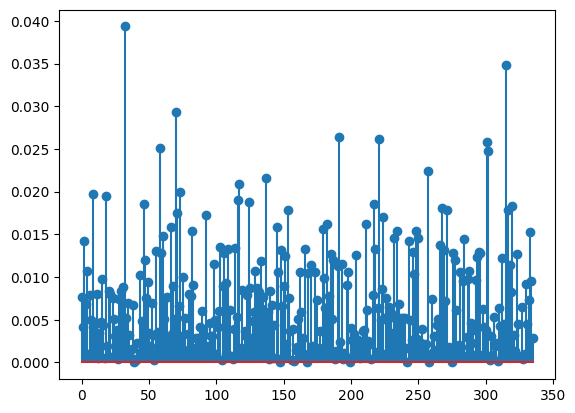

In [17]:
# nrSSSIndices  ind = k + (l * gridsize(1)) where k = (56, 183) and gridSize = [240 4]
# resource element (k, l) where k is subcarrier and l is OFDM symbols
# from ETSI TS 138 211 V15.4.0 (2019-04)
sssIndices = nrSSSIndices()         # sssIndices = 536-662   
# Extract resource element (SSS symbols) from resource grid (SS/PBCH block)
sssRx = nrExtractResources(sssIndices, rxGrid) 

# correlated recieved SSS symbols with each possible SSS sequence
sssEst = np.zeros(336)

for NID1 in np.arange(336):
    ncellid = (3*NID1) + select_NID2
    sssRef = nrSSS(ncellid)
    sssEst[NID1] = np.sum(np.abs(np.mean(sssRx * np.conj(sssRef))**2))

t_plot = np.arange(sssEst.shape[0])
plt.stem(t_plot, sssEst)

NID1 = np.argmax(sssEst)
print('NID1', NID1)